<a href="https://colab.research.google.com/github/Yasmina3/CBRA-FYP/blob/main/passive_time_series_simulator_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Passive time-series simulator v3 — stricter scientific calibration

This notebook upgrades the passive simulator from the previous v2 notebook into a **scientifically stricter v3 workflow**.

## What is different from v2

The main weakness in v2 was not code cleanliness anymore. It was the **validation design**.  
The simulator could look good on the old metrics while still not being strongly validated.

This v3 notebook addresses that by adding:

1. **Split-aware calibration**
   - bank split: used to build the empirical shape and increment banks
   - calibration split: used to tune parameters
   - validation split: held out until the end

2. **Multi-seed evaluation**
   - each candidate parameter set is evaluated across multiple stochastic repeats
   - selection is based on **mean score + variability penalty**, not one lucky run

3. **Sensor-level validation**
   - not only the breast global mean
   - also validates:
     - per-session median sensor drift
     - per-session median sensor temporal std
     - hottest-minus-coldest spread
     - mean absolute difference between real and synthetic sensor correlation matrices

4. **Label-conditional validation**
   - Healthy and Tumor are evaluated separately
   - prevents a misleading overall fit that hides class-specific mismatch

5. **Cleaner outputs**
   - everything is saved under a new folder:
     - `passive_simulator_v3_outputs/`
     - `passive_simulator_v3_outputs/config/`
     - `passive_simulator_v3_outputs/tables/`
     - `passive_simulator_v3_outputs/plots/`
     - `passive_simulator_v3_outputs/final_generation/`

## Scientific interpretation

This notebook still builds a **semi-parametric passive simulator** rather than a full mechanistic model.  
So the goal here is:

- preserve consistency with the real passive sessions,
- preserve consistency with the static COMSOL baseline,
- avoid overclaiming,
- and make the calibration/validation step much harder to fool.

Use this notebook as the **validation-grade passive simulator notebook**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from __future__ import annotations

from pathlib import Path
import json
import math
import warnings
from dataclasses import dataclass
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.stats import wasserstein_distance

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1) Project root and output folders

This cell detects the project root and creates a new output tree dedicated to v3.

In [ ]:
# ---- user override if needed ----
USER_DEFINED_ROOT = None
# Example:
# USER_DEFINED_ROOT = Path("/content/drive/MyDrive/clean-cbra")

REQUIRED_FILES = [
    "real_breast_level_timeseries_40sensors_cleaned_fullsessions.csv",
    "COMSOL_simulated-data_rebuilt.csv",
]

def resolve_project_root(user_defined_root=None) -> Path:
    candidates = []
    if user_defined_root is not None:
        candidates.append(Path(user_defined_root))
    candidates.extend([
        Path.cwd(),
        Path.cwd().parent,
        Path("/content/drive/MyDrive/clean-cbra"),
        Path("/mnt/data"),
    ])

    checked = []
    for root in candidates:
        root = root.expanduser().resolve()
        checked.append(root)
        if all((root / f).exists() for f in REQUIRED_FILES):
            return root

    checked_txt = "\n".join(str(p) for p in checked)
    raise FileNotFoundError(
        "Could not locate the project root automatically. "
        "Set USER_DEFINED_ROOT manually.\n\n"
        f"Checked:\n{checked_txt}"
    )

ROOT = resolve_project_root(USER_DEFINED_ROOT)

OUTPUT_DIR = ROOT / "passive_simulator_v3_outputs"
CONFIG_DIR = OUTPUT_DIR / "config"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
FINAL_DIR = OUTPUT_DIR / "final_generation"

for d in [OUTPUT_DIR, CONFIG_DIR, TABLE_DIR, PLOT_DIR, FINAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

REAL_FULL_PATH = ROOT / "real_breast_level_timeseries_40sensors_cleaned_fullsessions.csv"
COMSOL_PATH = ROOT / "COMSOL_simulated-data_rebuilt.csv"

print("ROOT:", ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("REAL_FULL_PATH exists:", REAL_FULL_PATH.exists())
print("COMSOL_PATH exists:", COMSOL_PATH.exists())

ROOT: /content/drive/MyDrive/clean-cbra
OUTPUT_DIR: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs
REAL_FULL_PATH exists: True
COMSOL_PATH exists: True


## 2) Load data

In [ ]:
SENSOR_COLS = [f"s_{i}" for i in range(1, 41)]
GROUP_COLS = ["test_ref", "side_array"]

real_full = pd.read_csv(REAL_FULL_PATH)
comsol = pd.read_csv(COMSOL_PATH)

required_real_cols = set(GROUP_COLS + ["time_step", "breast_label"] + SENSOR_COLS)
required_comsol_cols = set(["condition"] + SENSOR_COLS)

missing_real = sorted(required_real_cols - set(real_full.columns))
missing_comsol = sorted(required_comsol_cols - set(comsol.columns))

if missing_real:
    raise ValueError(f"Missing columns in real_full: {missing_real}")
if missing_comsol:
    raise ValueError(f"Missing columns in comsol: {missing_comsol}")

real_full = real_full.copy()
real_full["breast_label"] = real_full["breast_label"].astype(str)

label_map = {"Healthy": "Healthy", "Tumor": "Tumor"}
real_full = real_full[real_full["breast_label"].isin(label_map)].copy()
real_full["breast_label"] = real_full["breast_label"].map(label_map)

healthy_pool = comsol.loc[comsol["condition"] == "Healthy", SENSOR_COLS].to_numpy(dtype=float)
tumor_pool   = comsol.loc[comsol["condition"] == "Tumor", SENSOR_COLS].to_numpy(dtype=float)

if len(healthy_pool) == 0 or len(tumor_pool) == 0:
    raise ValueError("COMSOL pool must contain both Healthy and Tumor cases.")

print("real_full shape:", real_full.shape)
print("healthy_pool shape:", healthy_pool.shape)
print("tumor_pool shape:", tumor_pool.shape)
print("\nLabel distribution:")
display(real_full["breast_label"].value_counts())

real_full shape: (53722, 58)
healthy_pool shape: (228, 40)
tumor_pool shape: (329, 40)

Label distribution:


,count
breast_label,
Healthy,35080
Tumor,18642


## 3) Helper functions

These helpers cover:

- robust 1D cleaning and resampling
- per-session global metrics
- per-session sensor-level metrics
- summary tables
- calibration reports

In [ ]:
def finite_1d(x) -> np.ndarray:
    x = np.asarray(x, dtype=float).ravel()
    return x[np.isfinite(x)]

def resample_1d(x: np.ndarray, target_len: int) -> np.ndarray:
    x = finite_1d(x)
    if len(x) < 2:
        return np.full(target_len, np.nan, dtype=float)
    src = np.linspace(0.0, 1.0, len(x))
    dst = np.linspace(0.0, 1.0, target_len)
    f = interp1d(src, x, kind="linear", fill_value="extrapolate")
    return np.asarray(f(dst), dtype=float)

def safe_wd(a, b) -> float:
    a = finite_1d(a)
    b = finite_1d(b)
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return float(wasserstein_distance(a, b))

def safe_corrcoef_2d(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError("Expected 2D array.")
    with np.errstate(invalid="ignore"):
        corr = np.corrcoef(arr, rowvar=False)
    if np.isscalar(corr):
        corr = np.array([[1.0]])
    corr = np.asarray(corr, dtype=float)
    corr[~np.isfinite(corr)] = 0.0
    np.fill_diagonal(corr, 1.0)
    return corr

def upper_triangle_mean_abs_diff(a: np.ndarray, b: np.ndarray) -> float:
    if a.shape != b.shape:
        raise ValueError("Matrices must have the same shape.")
    iu = np.triu_indices_from(a, k=1)
    if len(iu[0]) == 0:
        return 0.0
    return float(np.mean(np.abs(a[iu] - b[iu])))

def session_metrics_from_dataframe(g: pd.DataFrame, n_curve_points: int = 100):
    g = g.sort_values("time_step")
    x = g[SENSOR_COLS].to_numpy(dtype=float)
    if x.shape[0] < 10:
        return None

    gm = np.nanmean(x, axis=1)
    n = len(gm)
    k = max(5, n // 10)

    first_mean = np.nanmean(gm[:k])
    second_mean = np.nanmean(gm[k:2*k]) if n >= 2*k else np.nan
    last_mean = np.nanmean(gm[-k:])

    total_drift = float(last_mean - first_mean)
    early_warmup = float(second_mean - first_mean) if np.isfinite(second_mean) else np.nan

    diff = np.diff(gm)
    if len(diff) < 2:
        return None

    lag1 = np.corrcoef(gm[:-1], gm[1:])[0, 1] if np.std(gm[:-1]) > 0 and np.std(gm[1:]) > 0 else np.nan
    lag3 = np.corrcoef(gm[:-3], gm[3:])[0, 1] if len(gm) > 6 and np.std(gm[:-3]) > 0 and np.std(gm[3:]) > 0 else np.nan
    diff_std = float(np.nanstd(diff))

    curve = gm - gm[0]
    curve = resample_1d(curve, n_curve_points)
    if not np.isfinite(curve).all():
        return None

    sensor_drift = x[-k:].mean(axis=0) - x[:k].mean(axis=0)
    sensor_temporal_std = x.std(axis=0)
    sensor_spread = x.max(axis=1) - x.min(axis=1)
    mean_spread = float(np.mean(sensor_spread))

    corr = safe_corrcoef_2d(x)

    return {
        "n_steps": int(n),
        "total_drift": total_drift,
        "early_warmup": early_warmup,
        "lag1_global_mean": float(lag1),
        "lag3_global_mean": float(lag3) if np.isfinite(lag3) else np.nan,
        "diff_std_global_mean": diff_std,
        "median_sensor_drift": float(np.median(sensor_drift)),
        "median_sensor_std": float(np.median(sensor_temporal_std)),
        "mean_hot_cold_spread": mean_spread,
        "curve": curve,
        "diff": diff,
        "corr": corr,
    }

def summary_from_session_metrics(per_session: pd.DataFrame) -> dict:
    cols = [
        "n_steps",
        "total_drift",
        "early_warmup",
        "lag1_global_mean",
        "lag3_global_mean",
        "diff_std_global_mean",
        "median_sensor_drift",
        "median_sensor_std",
        "mean_hot_cold_spread",
    ]
    df = per_session[cols].copy()
    out = {"n_session_sides": int(len(df))}
    for c in cols:
        out[f"median_{c}"] = float(np.nanmedian(df[c]))
        out[f"mean_{c}"] = float(np.nanmean(df[c]))
    return out

def median_curve_from_per_session(per_session: pd.DataFrame) -> np.ndarray:
    return np.nanmedian(np.vstack(per_session["curve"].to_numpy()), axis=0)

def median_corr_from_per_session(per_session: pd.DataFrame) -> np.ndarray:
    stack = np.stack(per_session["corr"].to_numpy(), axis=0)
    return np.nanmedian(stack, axis=0)

def calibration_report(real_per, synth_per):
    real_summary = summary_from_session_metrics(real_per)
    synth_summary = summary_from_session_metrics(synth_per)

    real_curve = median_curve_from_per_session(real_per)
    synth_curve = median_curve_from_per_session(synth_per)

    real_corr = median_corr_from_per_session(real_per)
    synth_corr = median_corr_from_per_session(synth_per)

    rep = {}

    rel_metrics = [
        ("drift_med_rel_err", "median_total_drift"),
        ("warm_med_rel_err", "median_early_warmup"),
        ("diff_med_rel_err", "median_diff_std_global_mean"),
        ("sensor_drift_med_rel_err", "median_median_sensor_drift"),
        ("sensor_std_med_rel_err", "median_median_sensor_std"),
        ("spread_med_rel_err", "median_mean_hot_cold_spread"),
    ]
    for out_name, key in rel_metrics:
        denom = max(abs(real_summary[key]), 1e-8)
        rep[out_name] = float(abs(synth_summary[key] - real_summary[key]) / denom)

    rep["lag1_abs_err"] = float(abs(
        synth_summary["median_lag1_global_mean"] - real_summary["median_lag1_global_mean"]
    ))
    rep["lag3_abs_err"] = float(abs(
        synth_summary["median_lag3_global_mean"] - real_summary["median_lag3_global_mean"]
    ))

    overlap = min(len(real_curve), len(synth_curve))
    rep["curve_rmse"] = float(np.sqrt(np.mean((real_curve[:overlap] - synth_curve[:overlap]) ** 2)))

    rep["wd_total_drift"] = safe_wd(real_per["total_drift"], synth_per["total_drift"])
    rep["wd_early_warmup"] = safe_wd(real_per["early_warmup"], synth_per["early_warmup"])
    rep["wd_diff_std"] = safe_wd(real_per["diff_std_global_mean"], synth_per["diff_std_global_mean"])
    rep["wd_sensor_std"] = safe_wd(real_per["median_sensor_std"], synth_per["median_sensor_std"])
    rep["wd_spread"] = safe_wd(real_per["mean_hot_cold_spread"], synth_per["mean_hot_cold_spread"])

    rep["corr_mae"] = upper_triangle_mean_abs_diff(real_corr, synth_corr)

    rep["score"] = float(
        1.0 * rep["drift_med_rel_err"] +
        1.0 * rep["warm_med_rel_err"] +
        1.5 * rep["diff_med_rel_err"] +
        0.5 * rep["lag1_abs_err"] / 1e-4 +
        0.5 * rep["lag3_abs_err"] / 1e-4 +
        1.5 * rep["curve_rmse"] +
        1.0 * rep["sensor_drift_med_rel_err"] +
        1.0 * rep["sensor_std_med_rel_err"] +
        1.0 * rep["spread_med_rel_err"] +
        1.0 * rep["wd_total_drift"] +
        0.8 * rep["wd_early_warmup"] +
        1.2 * rep["wd_diff_std"] +
        0.8 * rep["wd_sensor_std"] +
        0.8 * rep["wd_spread"] +
        1.2 * rep["corr_mae"]
    )

    thresholds = {
        "drift_med_rel_err": 0.15,
        "warm_med_rel_err": 0.15,
        "diff_med_rel_err": 0.20,
        "lag1_abs_err": 5e-5,
        "lag3_abs_err": 2e-4,
        "curve_rmse": 0.10,
        "sensor_drift_med_rel_err": 0.25,
        "sensor_std_med_rel_err": 0.20,
        "spread_med_rel_err": 0.20,
        "wd_total_drift": 0.20,
        "wd_early_warmup": 0.10,
        "wd_diff_std": 0.0025,
        "wd_sensor_std": 0.02,
        "wd_spread": 0.20,
        "corr_mae": 0.10,
    }

    for k, thr in thresholds.items():
        rep[f"{k}_pass"] = bool(np.isfinite(rep[k]) and rep[k] <= thr)
    rep["overall_pass"] = bool(all(rep[f"{k}_pass"] for k in thresholds))
    return rep

def calibration_report_by_label(real_per, synth_per):
    rows = []
    for label in sorted(real_per["breast_label"].unique()):
        real_sub = real_per[real_per["breast_label"] == label].reset_index(drop=True)
        synth_sub = synth_per[synth_per["breast_label"] == label].reset_index(drop=True)
        if len(real_sub) == 0 or len(synth_sub) == 0:
            continue
        rep = calibration_report(real_sub, synth_sub)
        rep["breast_label"] = label
        rows.append(rep)
    return pd.DataFrame(rows)

def save_json(obj, path: Path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def display_split_counts(session_df: pd.DataFrame, split_col: str = "split"):
    out = session_df.groupby([split_col, "breast_label"]).size().unstack(fill_value=0)
    return out

## 4) Session extraction and split

We first collapse the raw table into session-side objects, then create a **stratified split by label**.

The split philosophy is:

- **bank**: build empirical curve/increment banks
- **calib**: tune parameters
- **valid**: held out until model selection is done

In [ ]:
def build_session_table(real_df: pd.DataFrame, n_curve_points: int = 100) -> pd.DataFrame:
    rows = []
    for (test_ref, side_array), g in real_df.groupby(GROUP_COLS, sort=False):
        g = g.sort_values("time_step")
        m = session_metrics_from_dataframe(g, n_curve_points=n_curve_points)
        if m is None:
            continue
        rows.append({
            "test_ref": test_ref,
            "side_array": side_array,
            "breast_label": g["breast_label"].iloc[0],
            "n_steps": m["n_steps"],
            "total_drift": m["total_drift"],
            "early_warmup": m["early_warmup"],
            "lag1_global_mean": m["lag1_global_mean"],
            "lag3_global_mean": m["lag3_global_mean"],
            "diff_std_global_mean": m["diff_std_global_mean"],
            "median_sensor_drift": m["median_sensor_drift"],
            "median_sensor_std": m["median_sensor_std"],
            "mean_hot_cold_spread": m["mean_hot_cold_spread"],
            "curve": m["curve"],
            "diff": m["diff"],
            "corr": m["corr"],
        })
    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError("No valid real sessions were extracted.")
    return out

session_table = build_session_table(real_full)
session_table_nopath = session_table.drop(columns=["curve", "diff", "corr"]).copy()
session_table_nopath.to_csv(TABLE_DIR / "all_real_sessions_summary.csv", index=False)

print("Number of session-sides:", len(session_table))
display(session_table_nopath.head())

Number of session-sides: 92


,test_ref,side_array,breast_label,n_steps,total_drift,early_warmup,lag1_global_mean,lag3_global_mean,diff_std_global_mean,median_sensor_drift,median_sensor_std,mean_hot_cold_spread
0,Test-patiente-01-37-WJ,cg,Tumor,574,0.523627,0.120048,0.995399,0.985319,0.016889,0.600789,0.203924,2.802944
1,Test-Patiente-01-38-JF,cg,Tumor,551,1.259305,0.298441,0.999995,0.999987,0.002103,1.276545,0.414011,1.248421
2,Test_100_patiente_01-19-PM,cg,Tumor,586,1.383879,0.389698,0.999897,0.999582,0.006806,1.332500,0.426248,2.668976
3,Test_103_patiente_01-20-GD,cg,Healthy,585,1.611384,0.275599,0.999998,0.999995,0.001583,1.625862,0.523061,2.421248
4,Test_104_patiente_01-21-TC,cg,Tumor,588,1.737530,0.456401,0.999997,0.999991,0.002905,1.747414,0.543498,2.547585


In [ ]:
def stratified_three_way_split(
    df: pd.DataFrame,
    label_col: str = "breast_label",
    seed: int = 42,
    frac_bank: float = 0.50,
    frac_calib: float = 0.25,
    frac_valid: float = 0.25,
) -> pd.DataFrame:
    if not np.isclose(frac_bank + frac_calib + frac_valid, 1.0):
        raise ValueError("Split fractions must sum to 1.")

    rng = np.random.default_rng(seed)
    df = df.copy()
    df["split"] = None

    for label, sub in df.groupby(label_col):
        idx = sub.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)

        n_bank = max(1, int(round(frac_bank * n)))
        n_calib = max(1, int(round(frac_calib * n)))
        if n_bank + n_calib >= n:
            n_bank = max(1, n - 2)
            n_calib = 1
        n_valid = n - n_bank - n_calib
        if n_valid < 1:
            n_valid = 1
            if n_bank > n_calib:
                n_bank -= 1
            else:
                n_calib -= 1

        bank_idx = idx[:n_bank]
        calib_idx = idx[n_bank:n_bank+n_calib]
        valid_idx = idx[n_bank+n_calib:]

        df.loc[bank_idx, "split"] = "bank"
        df.loc[calib_idx, "split"] = "calib"
        df.loc[valid_idx, "split"] = "valid"

    if df["split"].isna().any():
        raise ValueError("Split assignment failed.")
    return df

session_splits = stratified_three_way_split(session_table, seed=42)
session_splits.drop(columns=["curve", "diff", "corr"]).to_csv(TABLE_DIR / "session_splits.csv", index=False)

display(display_split_counts(session_splits))

breast_label,Healthy,Tumor
split,,
bank,30,16
calib,15,8
valid,15,8


## 5) Build the empirical banks from the bank split only

In [ ]:
def build_banks_from_split(real_df: pd.DataFrame, split_sessions: pd.DataFrame, split_name: str = "bank"):
    keys = split_sessions.loc[split_sessions["split"] == split_name, GROUP_COLS].drop_duplicates()
    df = real_df.merge(keys, on=GROUP_COLS, how="inner")

    bank_sessions = build_session_table(df)

    curve_bank = bank_sessions[["test_ref", "side_array", "breast_label", "curve"]].copy()

    increment_bank = {}
    for label, sub in bank_sessions.groupby("breast_label"):
        seqs = []
        for arr in sub["diff"]:
            arr = finite_1d(arr)
            if len(arr) >= 20:
                seqs.append(arr)
        increment_bank[label] = seqs

    return df, bank_sessions, curve_bank, increment_bank

real_bank_df, bank_per_session, curve_bank, increment_bank = build_banks_from_split(real_full, session_splits, split_name="bank")

bank_per_session.drop(columns=["curve", "diff", "corr"]).to_csv(TABLE_DIR / "bank_sessions_summary.csv", index=False)

print("Bank raw shape:", real_bank_df.shape)
print("Bank session count:", len(bank_per_session))
for label, seqs in increment_bank.items():
    print(f"Increment bank[{label}] sequences:", len(seqs))

Bank raw shape: (26901, 58)
Bank session count: 46
Increment bank[Healthy] sequences: 30
Increment bank[Tumor] sequences: 16


## 6) Simulator

This is still the same simulator family in spirit as v2, but used inside a stricter evaluation design.

Main ingredients:

- static COMSOL baseline sampling
- empirical macro session curve bank
- block bootstrap of real increments
- low-frequency smooth perturbation
- sensor-level drift and AR(1) noise

In [ ]:
def sample_static_baseline(label: str, rng: np.random.Generator) -> np.ndarray:
    pool = healthy_pool if label == "Healthy" else tumor_pool
    return np.asarray(pool[rng.integers(len(pool))], dtype=float).copy()

def random_low_frequency_curve(n_steps: int, rng: np.random.Generator, scale: float) -> np.ndarray:
    if scale <= 0:
        return np.zeros(n_steps, dtype=float)
    x = np.linspace(0.0, 1.0, n_steps)
    a1, a2, a3 = rng.normal(0.0, 1.0, size=3)
    curve = (
        a1 * np.sin(np.pi * x) +
        a2 * np.sin(2 * np.pi * x) +
        a3 * np.sin(3 * np.pi * x)
    )
    curve = curve - curve[0]
    s = np.std(curve)
    if s > 0:
        curve = curve / s
    return scale * curve

def block_bootstrap_increments(bank: list[np.ndarray], target_len: int, block_size: int, rng: np.random.Generator) -> np.ndarray:
    if target_len <= 0:
        return np.zeros(0, dtype=float)
    if not bank:
        return np.zeros(target_len, dtype=float)

    out = []
    while len(out) < target_len:
        seq = bank[rng.integers(len(bank))]
        seq = finite_1d(seq)
        if len(seq) < block_size:
            continue
        start = int(rng.integers(0, len(seq) - block_size + 1))
        out.extend(seq[start:start + block_size].tolist())
    return np.asarray(out[:target_len], dtype=float)

def generate_passive_session(
    n_steps: int,
    label: str,
    rng: np.random.Generator,
    params: dict,
    curve_bank_df: pd.DataFrame,
    increment_bank_dict: dict,
) -> pd.DataFrame:
    baseline = sample_static_baseline(label, rng)
    baseline_mean = float(np.mean(baseline))

    sub = curve_bank_df[curve_bank_df["breast_label"] == label]
    if len(sub) == 0:
        sub = curve_bank_df

    template_curve = np.asarray(sub.iloc[rng.integers(len(sub))]["curve"], dtype=float)
    macro_curve = resample_1d(template_curve, n_steps)
    macro_curve = macro_curve - macro_curve[0]

    curve_scale = float(np.clip(
        rng.normal(params["curve_scale_mean"], params["curve_scale_sd"]),
        params["curve_scale_min"],
        params["curve_scale_max"],
    ))
    macro_curve = curve_scale * macro_curve

    inc_bank = increment_bank_dict.get(label, [])
    boot_diff = block_bootstrap_increments(
        bank=inc_bank,
        target_len=n_steps - 1,
        block_size=int(params["block_size"]),
        rng=rng,
    )

    residual_scale = float(np.clip(
        rng.normal(params["residual_scale_mean"], params["residual_scale_sd"]),
        0.0,
        params["residual_scale_max"],
    ))
    residual_curve = np.r_[0.0, np.cumsum(residual_scale * boot_diff)]
    residual_curve = residual_curve - residual_curve[0]
    residual_curve = residual_curve - np.linspace(0.0, residual_curve[-1], n_steps)

    low_freq = random_low_frequency_curve(
        n_steps=n_steps,
        rng=rng,
        scale=float(params["low_freq_sigma"]),
    )

    gm = baseline_mean + macro_curve + residual_curve + low_freq

    sensor_final_drift = rng.normal(0.0, params["sensor_drift_sigma"], size=40)
    sensor_drift = np.outer(np.linspace(0.0, 1.0, n_steps), sensor_final_drift)

    phi = float(params["sensor_phi"])
    noise_sigma = float(params["sensor_noise_sigma"])
    sensor_noise = np.zeros((n_steps, 40), dtype=float)
    eps = rng.normal(0.0, noise_sigma, size=(n_steps, 40))
    for t in range(1, n_steps):
        sensor_noise[t] = phi * sensor_noise[t - 1] + eps[t]

    x = gm[:, None] + (baseline - baseline_mean)[None, :] + sensor_drift + sensor_noise

    out = pd.DataFrame(x, columns=SENSOR_COLS)
    out.insert(0, "time_step", np.arange(n_steps, dtype=int))
    out.insert(0, "breast_label", label)
    return out

def simulate_dataset_from_session_spec(
    session_spec_df: pd.DataFrame,
    curve_bank_df: pd.DataFrame,
    increment_bank_dict: dict,
    params: dict,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)

    synth_rows = []
    per_rows = []

    for _, row in session_spec_df.iterrows():
        sim = generate_passive_session(
            n_steps=int(row["n_steps"]),
            label=row["breast_label"],
            rng=rng,
            params=params,
            curve_bank_df=curve_bank_df,
            increment_bank_dict=increment_bank_dict,
        )
        sim.insert(0, "side_array", row["side_array"])
        sim.insert(0, "test_ref", row["test_ref"])

        m = session_metrics_from_dataframe(sim)
        if m is None:
            continue

        per_rows.append({
            "test_ref": row["test_ref"],
            "side_array": row["side_array"],
            "breast_label": row["breast_label"],
            "n_steps": m["n_steps"],
            "total_drift": m["total_drift"],
            "early_warmup": m["early_warmup"],
            "lag1_global_mean": m["lag1_global_mean"],
            "lag3_global_mean": m["lag3_global_mean"],
            "diff_std_global_mean": m["diff_std_global_mean"],
            "median_sensor_drift": m["median_sensor_drift"],
            "median_sensor_std": m["median_sensor_std"],
            "mean_hot_cold_spread": m["mean_hot_cold_spread"],
            "curve": m["curve"],
            "diff": m["diff"],
            "corr": m["corr"],
        })
        synth_rows.append(sim)

    synth_df = pd.concat(synth_rows, axis=0, ignore_index=True)
    synth_per = pd.DataFrame(per_rows)
    return synth_df, synth_per

## 7) Real references for calibration and validation

In [ ]:
calib_real_per = session_splits.loc[session_splits["split"] == "calib"].reset_index(drop=True).copy()
valid_real_per = session_splits.loc[session_splits["split"] == "valid"].reset_index(drop=True).copy()

for name, df in [("calib", calib_real_per), ("valid", valid_real_per)]:
    df.drop(columns=["curve", "diff", "corr"]).to_csv(TABLE_DIR / f"{name}_real_sessions_summary.csv", index=False)

print("Calibration sessions:", len(calib_real_per))
print("Validation sessions:", len(valid_real_per))
display(display_split_counts(session_splits))

Calibration sessions: 23
Validation sessions: 23


breast_label,Healthy,Tumor
split,,
bank,30,16
calib,15,8
valid,15,8


## 8) Parameter search space

We keep a random search plus local refinement, but the candidate evaluation is now much stricter.

In [ ]:
def sample_random_params(rng: np.random.Generator) -> dict:
    block_size_choices = [8, 12, 16, 20, 24, 30]
    return {
        "curve_scale_mean": rng.uniform(0.92, 1.08),
        "curve_scale_sd": rng.uniform(0.01, 0.05),
        "curve_scale_min": 0.80,
        "curve_scale_max": 1.20,
        "residual_scale_mean": rng.uniform(0.10, 0.80),
        "residual_scale_sd": rng.uniform(0.02, 0.20),
        "residual_scale_max": 1.20,
        "block_size": int(rng.choice(block_size_choices)),
        "low_freq_sigma": rng.uniform(0.00, 0.08),
        "sensor_drift_sigma": rng.uniform(0.0005, 0.008),
        "sensor_noise_sigma": rng.uniform(0.00005, 0.0015),
        "sensor_phi": rng.uniform(0.80, 0.995),
    }

def local_grid_around(best_row: pd.Series):
    curve_means = np.clip(
        [best_row["curve_scale_mean"] - 0.03, best_row["curve_scale_mean"], best_row["curve_scale_mean"] + 0.03],
        0.80, 1.20
    )
    residual_means = np.clip(
        [best_row["residual_scale_mean"] - 0.10, best_row["residual_scale_mean"], best_row["residual_scale_mean"] + 0.10],
        0.00, 1.20
    )
    block_sizes = sorted(set([
        max(6, int(best_row["block_size"]) - 4),
        int(best_row["block_size"]),
        int(best_row["block_size"]) + 4,
    ]))
    noise_scales = np.clip(
        [best_row["sensor_noise_sigma"] * 0.7, best_row["sensor_noise_sigma"], best_row["sensor_noise_sigma"] * 1.3],
        1e-5, 0.005
    )
    low_freq_scales = np.clip(
        [max(0.0, best_row["low_freq_sigma"] - 0.02), best_row["low_freq_sigma"], best_row["low_freq_sigma"] + 0.02],
        0.0, 0.20
    )
    drift_scales = np.clip(
        [best_row["sensor_drift_sigma"] * 0.7, best_row["sensor_drift_sigma"], best_row["sensor_drift_sigma"] * 1.3],
        1e-5, 0.02
    )
    phis = np.clip(
        [best_row["sensor_phi"] - 0.03, best_row["sensor_phi"], best_row["sensor_phi"] + 0.03],
        0.75, 0.999
    )

    grid = []
    for cmean, rmean, b, ns, lf, ds, phi in product(
        curve_means, residual_means, block_sizes, noise_scales, low_freq_scales, drift_scales, phis
    ):
        grid.append({
            "curve_scale_mean": float(cmean),
            "curve_scale_sd": float(best_row["curve_scale_sd"]),
            "curve_scale_min": float(best_row["curve_scale_min"]),
            "curve_scale_max": float(best_row["curve_scale_max"]),
            "residual_scale_mean": float(rmean),
            "residual_scale_sd": float(best_row["residual_scale_sd"]),
            "residual_scale_max": float(best_row["residual_scale_max"]),
            "block_size": int(b),
            "low_freq_sigma": float(lf),
            "sensor_drift_sigma": float(ds),
            "sensor_noise_sigma": float(ns),
            "sensor_phi": float(phi),
        })
    return grid

## 9) Multi-seed candidate evaluation

This is the key methodological upgrade.

For each candidate:
- simulate the calibration split over several seeds
- compute overall and label-wise reports
- aggregate:
  - mean score
  - score standard deviation
  - pass rate
  - validation-style penalties from label mismatch

The ranking objective is intentionally conservative.

In [ ]:
def evaluate_candidate(
    params: dict,
    real_target_per: pd.DataFrame,
    curve_bank_df: pd.DataFrame,
    increment_bank_dict: dict,
    seeds: list[int],
):
    overall_rows = []
    label_rows = []

    for seed in seeds:
        _, synth_per = simulate_dataset_from_session_spec(
            session_spec_df=real_target_per,
            curve_bank_df=curve_bank_df,
            increment_bank_dict=increment_bank_dict,
            params=params,
            seed=seed,
        )

        rep = calibration_report(real_target_per, synth_per)
        rep["seed"] = seed
        overall_rows.append(rep)

        lbl = calibration_report_by_label(real_target_per, synth_per)
        if len(lbl):
            lbl["seed"] = seed
            label_rows.append(lbl)

    overall_df = pd.DataFrame(overall_rows)
    label_df = pd.concat(label_rows, axis=0, ignore_index=True) if label_rows else pd.DataFrame()

    summary = {}
    for col in overall_df.columns:
        if col.endswith("_pass") or col == "overall_pass":
            summary[f"{col}_rate"] = float(overall_df[col].mean())
        elif col != "seed":
            summary[f"{col}_mean"] = float(overall_df[col].mean())
            summary[f"{col}_std"] = float(overall_df[col].std(ddof=0))

    if len(label_df):
        numeric_cols = [c for c in label_df.columns if c not in ["breast_label", "seed"] and not c.endswith("_pass") and c != "overall_pass"]
        for label in sorted(label_df["breast_label"].unique()):
            sub = label_df[label_df["breast_label"] == label]
            summary[f"{label}_score_mean"] = float(sub["score"].mean())
            summary[f"{label}_score_std"] = float(sub["score"].std(ddof=0))
            summary[f"{label}_overall_pass_rate"] = float(sub["overall_pass"].mean())

    # Conservative selection criterion:
    # mean performance + variability penalty + label imbalance penalty + low pass-rate penalty
    mean_score = summary["score_mean"]
    std_penalty = 0.50 * summary.get("score_std", 0.0)
    low_pass_penalty = 2.0 * (1.0 - summary.get("overall_pass_rate", 0.0))

    label_penalty = 0.0
    if "Healthy_score_mean" in summary and "Tumor_score_mean" in summary:
        label_penalty += 0.25 * abs(summary["Healthy_score_mean"] - summary["Tumor_score_mean"])
    if "Healthy_overall_pass_rate" in summary and "Tumor_overall_pass_rate" in summary:
        label_penalty += 1.0 * abs(summary["Healthy_overall_pass_rate"] - summary["Tumor_overall_pass_rate"])

    summary["robust_objective"] = float(mean_score + std_penalty + low_pass_penalty + label_penalty)
    summary["n_seeds"] = int(len(seeds))
    return summary, overall_df, label_df

## 10) Random search on the calibration split

In [ ]:
RANDOM_SEARCH_PATH = TABLE_DIR / "random_search_results.csv"
RANDOM_SEARCH_DETAIL_PATH = TABLE_DIR / "random_search_results_detailed.csv"
RANDOM_LABEL_DETAIL_PATH = TABLE_DIR / "random_search_labelwise_detailed.csv"

SEARCH_SEED = 42
rng = np.random.default_rng(SEARCH_SEED)

N_RANDOM = 80
CALIB_SEEDS = [1000, 1001, 1002, 1003]

random_rows = []
random_detail_rows = []
random_label_rows = []

for candidate_id in range(N_RANDOM):
    params = sample_random_params(rng)
    summary, detail_df, label_df = evaluate_candidate(
        params=params,
        real_target_per=calib_real_per,
        curve_bank_df=curve_bank,
        increment_bank_dict=increment_bank,
        seeds=CALIB_SEEDS,
    )
    random_rows.append({"stage": "random", "candidate_id": candidate_id, **params, **summary})

    tmp = detail_df.copy()
    tmp.insert(0, "candidate_id", candidate_id)
    tmp.insert(0, "stage", "random")
    random_detail_rows.append(tmp)

    if len(label_df):
        lbl = label_df.copy()
        lbl.insert(0, "candidate_id", candidate_id)
        lbl.insert(0, "stage", "random")
        random_label_rows.append(lbl)

random_df = pd.DataFrame(random_rows).sort_values("robust_objective").reset_index(drop=True)
random_detail_df = pd.concat(random_detail_rows, axis=0, ignore_index=True)
random_label_df = pd.concat(random_label_rows, axis=0, ignore_index=True) if random_label_rows else pd.DataFrame()

random_df.to_csv(RANDOM_SEARCH_PATH, index=False)
random_detail_df.to_csv(RANDOM_SEARCH_DETAIL_PATH, index=False)
if len(random_label_df):
    random_label_df.to_csv(RANDOM_LABEL_DETAIL_PATH, index=False)

print("Saved:", RANDOM_SEARCH_PATH)
display(random_df.head(10))

Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/tables/random_search_results.csv


,stage,candidate_id,curve_scale_mean,curve_scale_sd,curve_scale_min,curve_scale_max,residual_scale_mean,residual_scale_sd,residual_scale_max,block_size,low_freq_sigma,sensor_drift_sigma,sensor_noise_sigma,sensor_phi,drift_med_rel_err_mean,drift_med_rel_err_std,warm_med_rel_err_mean,warm_med_rel_err_std,diff_med_rel_err_mean,diff_med_rel_err_std,sensor_drift_med_rel_err_mean,sensor_drift_med_rel_err_std,sensor_std_med_rel_err_mean,sensor_std_med_rel_err_std,spread_med_rel_err_mean,spread_med_rel_err_std,lag1_abs_err_mean,lag1_abs_err_std,lag3_abs_err_mean,lag3_abs_err_std,curve_rmse_mean,curve_rmse_std,wd_total_drift_mean,wd_total_drift_std,wd_early_warmup_mean,wd_early_warmup_std,wd_diff_std_mean,wd_diff_std_std,wd_sensor_std_mean,wd_sensor_std_std,wd_spread_mean,wd_spread_std,corr_mae_mean,corr_mae_std,score_mean,score_std,drift_med_rel_err_pass_rate,warm_med_rel_err_pass_rate,diff_med_rel_err_pass_rate,lag1_abs_err_pass_rate,lag3_abs_err_pass_rate,curve_rmse_pass_rate,sensor_drift_med_rel_err_pass_rate,sensor_std_med_rel_err_pass_rate,spread_med_rel_err_pass_rate,wd_total_drift_pass_rate,wd_early_warmup_pass_rate,wd_diff_std_pass_rate,wd_sensor_std_pass_rate,wd_spread_pass_rate,corr_mae_pass_rate,overall_pass_rate,Healthy_score_mean,Healthy_score_std,Healthy_overall_pass_rate,Tumor_score_mean,Tumor_score_std,Tumor_overall_pass_rate,robust_objective,n_seeds
0,random,8,0.924931,0.027469,0.8,1.2,0.250209,0.093535,1.2,30,0.018715,0.000937,0.000458,0.857251,0.082882,0.043139,0.138632,0.053017,0.129946,0.061266,0.118722,0.041429,0.123026,0.033964,0.674109,0.005137,0.000008,0.000004,0.000022,0.000025,0.091736,0.026074,0.111102,0.033374,0.044970,0.010140,0.001919,0.000271,0.050862,0.007358,1.452145,0.027266,0.007249,4.394914e-07,2.982184,0.313871,1.0,0.75,0.75,1.0,1.0,0.50,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,3.888853,0.487511,0.0,6.432863,1.080539,0.0,5.775122,4
1,random,11,0.968242,0.035211,0.8,1.2,0.353269,0.035777,1.2,20,0.009440,0.007714,0.001367,0.936443,0.049658,0.058744,0.118135,0.071158,0.076885,0.063868,0.066573,0.027375,0.079773,0.020228,0.658573,0.004224,0.000011,0.000003,0.000012,0.000007,0.111032,0.063150,0.146293,0.016300,0.054400,0.004350,0.002080,0.000219,0.049327,0.008817,1.360654,0.052558,0.007175,8.184813e-06,2.697424,0.113388,1.0,0.75,1.00,1.0,1.0,0.50,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,3.215959,0.218258,0.0,7.439530,1.091892,0.0,5.810011,4
2,random,24,0.922230,0.019186,0.8,1.2,0.192276,0.141979,1.2,30,0.040506,0.005707,0.000893,0.838956,0.077460,0.035826,0.124065,0.090873,0.184114,0.076346,0.112951,0.034038,0.108080,0.044416,0.670983,0.004926,0.000011,0.000004,0.000024,0.000019,0.087864,0.029584,0.111912,0.030638,0.046640,0.008273,0.001996,0.000314,0.049106,0.007622,1.446377,0.026564,0.007236,1.600640e-06,3.033251,0.310381,1.0,0.75,0.50,1.0,1.0,0.50,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,3.861698,0.521265,0.0,6.458463,1.083975,0.0,5.837633,4
3,random,22,0.935115,0.039872,0.8,1.2,0.283722,0.188626,1.2,30,0.009821,0.006733,0.000272,0.834957,0.076694,0.049061,0.172736,0.068145,0.077791,0.037295,0.112589,0.047169,0.124729,0.038550,0.671106,0.005008,0.000008,0.000005,0.000040,0.000031,0.095406,0.022976,0.107985,0.036370,0.045209,0.010168,0.001754,0.000339,0.050228,0.007249,1.446427,0.026441,0.007252,3.027792e-07,3.007317,0.315110,1.0,0.50,1.00,1.0,1.0,0.50,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,3.670838,0.544487,0.0,6.490560,1.192433,0.0,5.869802,4
4,random,19,0.956834,0.011497,0.8,1.2,0.488397,0.086766,1.2,20,0.066383,0.006562,0.000510,0.985815,0.028162,0.015349,0.146289,0.077039,0.086079,0.048016,0.046517,0.024015,0.021448,0.018325,0.660081,0.004209,0.000006,0.000003,0.000050,0.000024,0.111955,0.058934,0.141490,0.014799,0.056491,0.009638,0.001928,0.000346,0.045930,0.011251,1.363714,0.052552,0.007224,2.244559e-06,2.807873,0.242879,1.0,0.50,1.00,1.0,1.0,0.50,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,3.021133,0.233204,0.0,7.015339,1.197014,0.0,5.927864,4
5,random,64,0.942655,0.027930,0.8,1.2,0.374801,0.034409

## 11) Local refinement around the strongest random candidates

In [ ]:
REFINE_PATH = TABLE_DIR / "refined_search_results.csv"
REFINE_DETAIL_PATH = TABLE_DIR / "refined_search_results_detailed.csv"
REFINE_LABEL_DETAIL_PATH = TABLE_DIR / "refined_search_labelwise_detailed.csv"

TOPK = 3
top_random = random_df.head(TOPK).copy()

ref_rows = []
ref_detail_rows = []
ref_label_rows = []

candidate_counter = 0
for parent_rank, (_, best_row) in enumerate(top_random.iterrows()):
    grid = local_grid_around(best_row)

    # Keep the refinement size manageable
    max_refine = min(len(grid), 300)
    for params in grid[:max_refine]:
        summary, detail_df, label_df = evaluate_candidate(
            params=params,
            real_target_per=calib_real_per,
            curve_bank_df=curve_bank,
            increment_bank_dict=increment_bank,
            seeds=CALIB_SEEDS,
        )

        ref_rows.append({
            "stage": f"refine_from_rank_{parent_rank}",
            "parent_random_rank": parent_rank,
            "candidate_id": candidate_counter,
            **params,
            **summary,
        })

        tmp = detail_df.copy()
        tmp.insert(0, "candidate_id", candidate_counter)
        tmp.insert(0, "parent_random_rank", parent_rank)
        tmp.insert(0, "stage", f"refine_from_rank_{parent_rank}")
        ref_detail_rows.append(tmp)

        if len(label_df):
            lbl = label_df.copy()
            lbl.insert(0, "candidate_id", candidate_counter)
            lbl.insert(0, "parent_random_rank", parent_rank)
            lbl.insert(0, "stage", f"refine_from_rank_{parent_rank}")
            ref_label_rows.append(lbl)

        candidate_counter += 1

refined_df = pd.DataFrame(ref_rows).sort_values("robust_objective").reset_index(drop=True)
refined_detail_df = pd.concat(ref_detail_rows, axis=0, ignore_index=True)
refined_label_df = pd.concat(ref_label_rows, axis=0, ignore_index=True) if ref_label_rows else pd.DataFrame()

refined_df.to_csv(REFINE_PATH, index=False)
refined_detail_df.to_csv(REFINE_DETAIL_PATH, index=False)
if len(refined_label_df):
    refined_label_df.to_csv(REFINE_LABEL_DETAIL_PATH, index=False)

print("Saved:", REFINE_PATH)
display(refined_df.head(10))

Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/tables/refined_search_results.csv


,stage,parent_random_rank,candidate_id,curve_scale_mean,curve_scale_sd,curve_scale_min,curve_scale_max,residual_scale_mean,residual_scale_sd,residual_scale_max,block_size,low_freq_sigma,sensor_drift_sigma,sensor_noise_sigma,sensor_phi,drift_med_rel_err_mean,drift_med_rel_err_std,warm_med_rel_err_mean,warm_med_rel_err_std,diff_med_rel_err_mean,diff_med_rel_err_std,sensor_drift_med_rel_err_mean,sensor_drift_med_rel_err_std,sensor_std_med_rel_err_mean,sensor_std_med_rel_err_std,spread_med_rel_err_mean,spread_med_rel_err_std,lag1_abs_err_mean,lag1_abs_err_std,lag3_abs_err_mean,lag3_abs_err_std,curve_rmse_mean,curve_rmse_std,wd_total_drift_mean,wd_total_drift_std,wd_early_warmup_mean,wd_early_warmup_std,wd_diff_std_mean,wd_diff_std_std,wd_sensor_std_mean,wd_sensor_std_std,wd_spread_mean,wd_spread_std,corr_mae_mean,corr_mae_std,score_mean,score_std,drift_med_rel_err_pass_rate,warm_med_rel_err_pass_rate,diff_med_rel_err_pass_rate,lag1_abs_err_pass_rate,lag3_abs_err_pass_rate,curve_rmse_pass_rate,sensor_drift_med_rel_err_pass_rate,sensor_std_med_rel_err_pass_rate,spread_med_rel_err_pass_rate,wd_total_drift_pass_rate,wd_early_warmup_pass_rate,wd_diff_std_pass_rate,wd_sensor_std_pass_rate,wd_spread_pass_rate,corr_mae_pass_rate,overall_pass_rate,Healthy_score_mean,Healthy_score_std,Healthy_overall_pass_rate,Tumor_score_mean,Tumor_score_std,Tumor_overall_pass_rate,robust_objective,n_seeds
0,refine_from_rank_0,0,224,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.001218,0.000595,0.887251,0.114502,0.075171,0.159042,0.070196,0.090745,0.042139,0.116585,0.094144,0.106157,0.100715,0.663993,0.006345,0.000012,0.000006,0.000021,0.00002,0.101724,0.018018,0.139078,0.053386,0.047401,0.014148,0.002118,0.000221,0.056656,0.021237,1.435261,0.049501,0.007244,0.000003,2.993924,0.349439,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737027,0.516149,0.0,5.446060,0.698569,0.0,5.595902,4
1,refine_from_rank_0,0,223,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.001218,0.000595,0.857251,0.114502,0.075169,0.158994,0.070248,0.090723,0.042108,0.116588,0.094145,0.106153,0.100742,0.664111,0.006389,0.000012,0.000006,0.000021,0.00002,0.101727,0.018021,0.139083,0.053392,0.047400,0.014141,0.002118,0.000221,0.056659,0.021240,1.435571,0.049507,0.007246,0.000002,2.994150,0.349403,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737232,0.515882,0.0,5.446046,0.698604,0.0,5.596054,4
2,refine_from_rank_0,0,221,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.000937,0.000595,0.887251,0.114501,0.075156,0.159054,0.070189,0.090745,0.042139,0.116612,0.094165,0.106170,0.100644,0.664067,0.006396,0.000012,0.000006,0.000021,0.00002,0.101726,0.018016,0.139083,0.053381,0.047401,0.014148,0.002118,0.000221,0.056656,0.021234,1.435448,0.049498,0.007244,0.000003,2.994191,0.349362,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737354,0.516212,0.0,5.446159,0.698538,0.0,5.596073,4
3,refine_from_rank_0,0,222,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.001218,0.000595,0.827251,0.114502,0.075168,0.158961,0.070283,0.090698,0.042086,0.116609,0.094207,0.106155,0.100728,0.664194,0.006420,0.000012,0.000006,0.000021,0.00002,0.101729,0.018024,0.139086,0.053395,0.047399,0.014136,0.002118,0.000221,0.056657,0.021240,1.435789,0.049511,0.007247,0.000002,2.994303,0.349398,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737378,0.515676,0.0,5.445972,0.698684,0.0,5.596150,4
4,refine_from_rank_0,0,220,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.000937,0.000595,0.857251,0.114501,0.075154,0.159006,0.070241,0.090723,0.042108,0.116602,0.094144,0.106173,0.100703,0.664190,0.006443,0.000012,0.000006,0.000021,0.00002,0.101729,0.018020,0.139088,0.053387,0.047400,0.014141,0.002118,0.000221,0.056660,0.021236,1.435770,0.049503,0.007246,0.000002,2.994427,0.349371,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737629,0.515928,0.0,5.446159,0.698562,0.0,5.596245,4


## 12) Select the final calibration candidate

Selection rule:
- combine random and refined candidates
- sort by robust objective
- keep the strongest candidate
- save the parameter JSON

In [ ]:
ALL_SEARCH_PATH = TABLE_DIR / "all_search_results_ranked.csv"
BEST_PARAMS_PATH = CONFIG_DIR / "best_params_v3.json"

all_search = pd.concat([random_df, refined_df], axis=0, ignore_index=True).sort_values("robust_objective").reset_index(drop=True)
all_search.to_csv(ALL_SEARCH_PATH, index=False)

best_row = all_search.iloc[0].copy()

best_params = {
    "curve_scale_mean": float(best_row["curve_scale_mean"]),
    "curve_scale_sd": float(best_row["curve_scale_sd"]),
    "curve_scale_min": float(best_row["curve_scale_min"]),
    "curve_scale_max": float(best_row["curve_scale_max"]),
    "residual_scale_mean": float(best_row["residual_scale_mean"]),
    "residual_scale_sd": float(best_row["residual_scale_sd"]),
    "residual_scale_max": float(best_row["residual_scale_max"]),
    "block_size": int(best_row["block_size"]),
    "low_freq_sigma": float(best_row["low_freq_sigma"]),
    "sensor_drift_sigma": float(best_row["sensor_drift_sigma"]),
    "sensor_noise_sigma": float(best_row["sensor_noise_sigma"]),
    "sensor_phi": float(best_row["sensor_phi"]),
}

save_json(best_params, BEST_PARAMS_PATH)

print("Saved:", BEST_PARAMS_PATH)
print(json.dumps(best_params, indent=2))
display(all_search.head(10))

Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/config/best_params_v3.json
{
  "curve_scale_mean": 0.8949308535308703,
  "curve_scale_sd": 0.027468695569294495,
  "curve_scale_min": 0.8,
  "curve_scale_max": 1.2,
  "residual_scale_mean": 0.15020927097367046,
  "residual_scale_sd": 0.09353515587043452,
  "residual_scale_max": 1.2,
  "block_size": 34,
  "low_freq_sigma": 0.0,
  "sensor_drift_sigma": 0.0012184517314683936,
  "sensor_noise_sigma": 0.0005954086364614636,
  "sensor_phi": 0.8872507827645033
}


,stage,candidate_id,curve_scale_mean,curve_scale_sd,curve_scale_min,curve_scale_max,residual_scale_mean,residual_scale_sd,residual_scale_max,block_size,low_freq_sigma,sensor_drift_sigma,sensor_noise_sigma,sensor_phi,drift_med_rel_err_mean,drift_med_rel_err_std,warm_med_rel_err_mean,warm_med_rel_err_std,diff_med_rel_err_mean,diff_med_rel_err_std,sensor_drift_med_rel_err_mean,sensor_drift_med_rel_err_std,sensor_std_med_rel_err_mean,sensor_std_med_rel_err_std,spread_med_rel_err_mean,spread_med_rel_err_std,lag1_abs_err_mean,lag1_abs_err_std,lag3_abs_err_mean,lag3_abs_err_std,curve_rmse_mean,curve_rmse_std,wd_total_drift_mean,wd_total_drift_std,wd_early_warmup_mean,wd_early_warmup_std,wd_diff_std_mean,wd_diff_std_std,wd_sensor_std_mean,wd_sensor_std_std,wd_spread_mean,wd_spread_std,corr_mae_mean,corr_mae_std,score_mean,score_std,drift_med_rel_err_pass_rate,warm_med_rel_err_pass_rate,diff_med_rel_err_pass_rate,lag1_abs_err_pass_rate,lag3_abs_err_pass_rate,curve_rmse_pass_rate,sensor_drift_med_rel_err_pass_rate,sensor_std_med_rel_err_pass_rate,spread_med_rel_err_pass_rate,wd_total_drift_pass_rate,wd_early_warmup_pass_rate,wd_diff_std_pass_rate,wd_sensor_std_pass_rate,wd_spread_pass_rate,corr_mae_pass_rate,overall_pass_rate,Healthy_score_mean,Healthy_score_std,Healthy_overall_pass_rate,Tumor_score_mean,Tumor_score_std,Tumor_overall_pass_rate,robust_objective,n_seeds,parent_random_rank
0,refine_from_rank_0,224,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.001218,0.000595,0.887251,0.114502,0.075171,0.159042,0.070196,0.090745,0.042139,0.116585,0.094144,0.106157,0.100715,0.663993,0.006345,0.000012,0.000006,0.000021,0.00002,0.101724,0.018018,0.139078,0.053386,0.047401,0.014148,0.002118,0.000221,0.056656,0.021237,1.435261,0.049501,0.007244,0.000003,2.993924,0.349439,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737027,0.516149,0.0,5.446060,0.698569,0.0,5.595902,4,0.0
1,refine_from_rank_0,223,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.001218,0.000595,0.857251,0.114502,0.075169,0.158994,0.070248,0.090723,0.042108,0.116588,0.094145,0.106153,0.100742,0.664111,0.006389,0.000012,0.000006,0.000021,0.00002,0.101727,0.018021,0.139083,0.053392,0.047400,0.014141,0.002118,0.000221,0.056659,0.021240,1.435571,0.049507,0.007246,0.000002,2.994150,0.349403,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737232,0.515882,0.0,5.446046,0.698604,0.0,5.596054,4,0.0
2,refine_from_rank_0,221,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.000937,0.000595,0.887251,0.114501,0.075156,0.159054,0.070189,0.090745,0.042139,0.116612,0.094165,0.106170,0.100644,0.664067,0.006396,0.000012,0.000006,0.000021,0.00002,0.101726,0.018016,0.139083,0.053381,0.047401,0.014148,0.002118,0.000221,0.056656,0.021234,1.435448,0.049498,0.007244,0.000003,2.994191,0.349362,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737354,0.516212,0.0,5.446159,0.698538,0.0,5.596073,4,0.0
3,refine_from_rank_0,222,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.001218,0.000595,0.827251,0.114502,0.075168,0.158961,0.070283,0.090698,0.042086,0.116609,0.094207,0.106155,0.100728,0.664194,0.006420,0.000012,0.000006,0.000021,0.00002,0.101729,0.018024,0.139086,0.053395,0.047399,0.014136,0.002118,0.000221,0.056657,0.021240,1.435789,0.049511,0.007247,0.000002,2.994303,0.349398,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737378,0.515676,0.0,5.445972,0.698684,0.0,5.596150,4,0.0
4,refine_from_rank_0,220,0.894931,0.027469,0.8,1.2,0.150209,0.093535,1.2,34,0.0,0.000937,0.000595,0.857251,0.114501,0.075154,0.159006,0.070241,0.090723,0.042108,0.116602,0.094144,0.106173,0.100703,0.664190,0.006443,0.000012,0.000006,0.000021,0.00002,0.101729,0.018020,0.139088,0.053387,0.047400,0.014141,0.002118,0.000221,0.056660,0.021236,1.435770,0.049503,0.007246,0.000002,2.994427,0.349371,0.75,0.5,1.0,1.0,1.0,0.75,0.75,0.75,0.0,0.75,1.0,1.0,0.0,0.0,1.0,0.0,3.737629,0.515928,0.0,5.446159,0.698562,0.0,5.596

## 13) Repeatability check on calibration split with the selected parameters

In [ ]:
CALIB_REPEAT_SUMMARY_PATH = TABLE_DIR / "calibration_repeatability_summary.csv"
CALIB_REPEAT_LABEL_PATH = TABLE_DIR / "calibration_repeatability_labelwise.csv"

REPEAT_SEEDS = [5000 + i for i in range(12)]
calib_summary, calib_detail_df, calib_label_df = evaluate_candidate(
    params=best_params,
    real_target_per=calib_real_per,
    curve_bank_df=curve_bank,
    increment_bank_dict=increment_bank,
    seeds=REPEAT_SEEDS,
)

calib_detail_df.to_csv(CALIB_REPEAT_SUMMARY_PATH, index=False)
if len(calib_label_df):
    calib_label_df.to_csv(CALIB_REPEAT_LABEL_PATH, index=False)

print("Saved:", CALIB_REPEAT_SUMMARY_PATH)
print("Calibration repeatability summary:")
print(json.dumps({k: v for k, v in calib_summary.items() if not k.startswith("Healthy_") and not k.startswith("Tumor_")}, indent=2))

Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/tables/calibration_repeatability_summary.csv
Calibration repeatability summary:
{
  "drift_med_rel_err_mean": 0.09569584766632344,
  "drift_med_rel_err_std": 0.06497904726357837,
  "warm_med_rel_err_mean": 0.0998847488915768,
  "warm_med_rel_err_std": 0.09742804023395438,
  "diff_med_rel_err_mean": 0.23793562086094677,
  "diff_med_rel_err_std": 0.12162282690768494,
  "sensor_drift_med_rel_err_mean": 0.10503308117873487,
  "sensor_drift_med_rel_err_std": 0.059397020292057776,
  "sensor_std_med_rel_err_mean": 0.11737606196469925,
  "sensor_std_med_rel_err_std": 0.06878609625291045,
  "spread_med_rel_err_mean": 0.6698257420607385,
  "spread_med_rel_err_std": 0.02229973286401139,
  "lag1_abs_err_mean": 1.6162583291734478e-05,
  "lag1_abs_err_std": 4.6962739615126024e-06,
  "lag3_abs_err_mean": 3.542389039602282e-05,
  "lag3_abs_err_std": 2.6049802274936908e-05,
  "curve_rmse_mean": 0.11589738890629196,
  "curve_rmse_std"

## 14) Held-out validation

This is the real scientific test of whether the selected parameters generalize beyond the calibration split.

In [ ]:
VALID_OVERALL_PATH = TABLE_DIR / "validation_repeatability_summary.csv"
VALID_LABEL_PATH = TABLE_DIR / "validation_repeatability_labelwise.csv"
VALID_AGG_JSON = CONFIG_DIR / "validation_aggregate_report.json"

valid_summary, valid_detail_df, valid_label_df = evaluate_candidate(
    params=best_params,
    real_target_per=valid_real_per,
    curve_bank_df=curve_bank,
    increment_bank_dict=increment_bank,
    seeds=REPEAT_SEEDS,
)

valid_detail_df.to_csv(VALID_OVERALL_PATH, index=False)
if len(valid_label_df):
    valid_label_df.to_csv(VALID_LABEL_PATH, index=False)

save_json(valid_summary, VALID_AGG_JSON)

print("Saved:", VALID_OVERALL_PATH)
print("Saved:", VALID_AGG_JSON)
print(json.dumps(valid_summary, indent=2))

Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/tables/validation_repeatability_summary.csv
Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/config/validation_aggregate_report.json
{
  "drift_med_rel_err_mean": 0.15503085692028926,
  "drift_med_rel_err_std": 0.09125444704320336,
  "warm_med_rel_err_mean": 0.1981688081910444,
  "warm_med_rel_err_std": 0.07764893162216,
  "diff_med_rel_err_mean": 0.3937983625549358,
  "diff_med_rel_err_std": 0.06532720117001406,
  "sensor_drift_med_rel_err_mean": 0.14857312731435016,
  "sensor_drift_med_rel_err_std": 0.08689168093030447,
  "sensor_std_med_rel_err_mean": 0.13265383184169716,
  "sensor_std_med_rel_err_std": 0.08412183135565501,
  "spread_med_rel_err_mean": 0.5994262902873454,
  "spread_med_rel_err_std": 0.020604504065375753,
  "lag1_abs_err_mean": 1.6209446384529702e-05,
  "lag1_abs_err_std": 7.160422369778335e-06,
  "lag3_abs_err_mean": 4.8253191824600604e-05,
  "lag3_abs_err_std": 2.670477720400

## 15) Scientific QA gate

This explicit gate is the notebook's final decision logic.

The simulator is considered **scientifically acceptable at this stage** only if:

- calibration repeatability is stable,
- held-out validation is acceptable,
- and class-specific pass rates are not badly imbalanced.

In [ ]:
def scientific_gate(calib_summary: dict, valid_summary: dict) -> dict:
    out = {}

    out["calib_overall_pass_rate_ok"] = bool(calib_summary.get("overall_pass_rate", 0.0) >= 0.80)
    out["calib_score_std_ok"] = bool(calib_summary.get("score_std", np.inf) <= 0.15)
    out["valid_overall_pass_rate_ok"] = bool(valid_summary.get("overall_pass_rate", 0.0) >= 0.70)
    out["valid_score_mean_ok"] = bool(valid_summary.get("score_mean", np.inf) <= 1.25 * calib_summary.get("score_mean", np.inf))
    out["valid_score_std_ok"] = bool(valid_summary.get("score_std", np.inf) <= 0.20)

    if "Healthy_overall_pass_rate" in valid_summary and "Tumor_overall_pass_rate" in valid_summary:
        out["label_balance_ok"] = bool(abs(
            valid_summary["Healthy_overall_pass_rate"] - valid_summary["Tumor_overall_pass_rate"]
        ) <= 0.30)
    else:
        out["label_balance_ok"] = False

    out["overall_scientific_acceptance"] = bool(all(out.values()))
    return out

qa_gate = scientific_gate(calib_summary, valid_summary)
QA_GATE_PATH = CONFIG_DIR / "scientific_qa_gate.json"
save_json(qa_gate, QA_GATE_PATH)

print(json.dumps(qa_gate, indent=2))

{
  "calib_overall_pass_rate_ok": false,
  "calib_score_std_ok": false,
  "valid_overall_pass_rate_ok": false,
  "valid_score_mean_ok": true,
  "valid_score_std_ok": false,
  "label_balance_ok": true,
  "overall_scientific_acceptance": false
}


## 16) Diagnostic plots

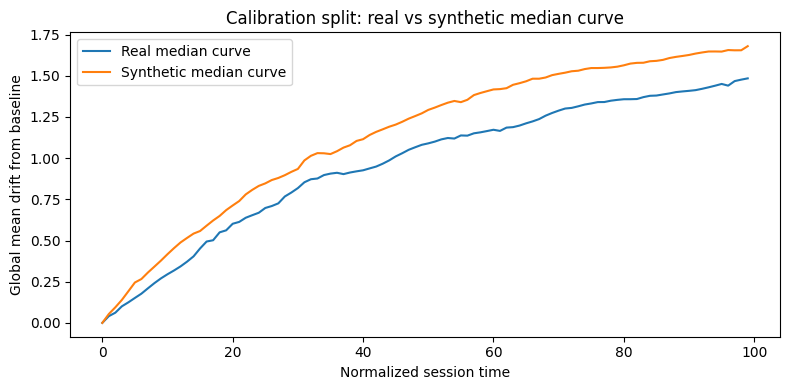

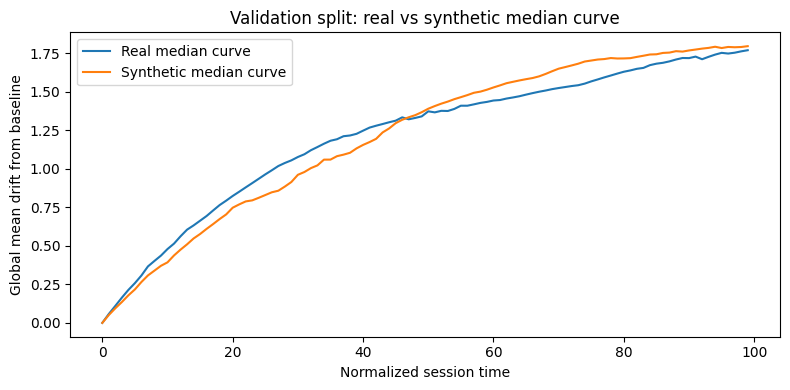

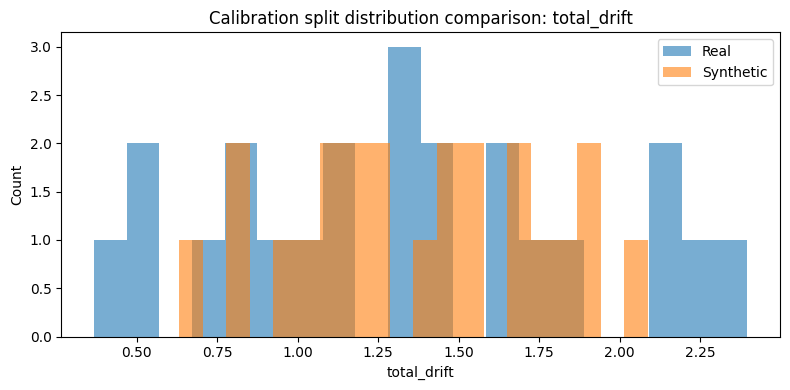

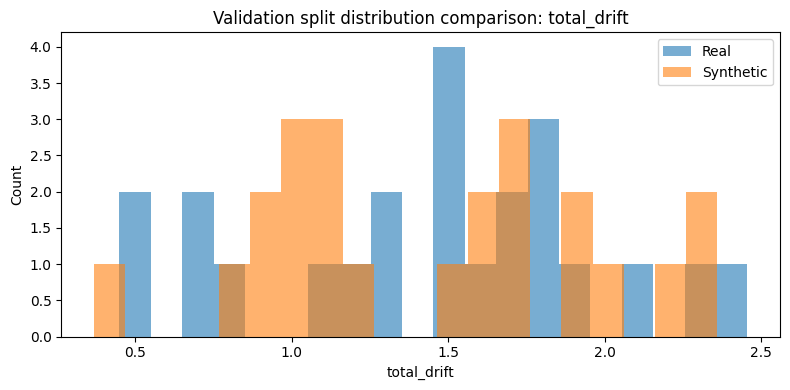

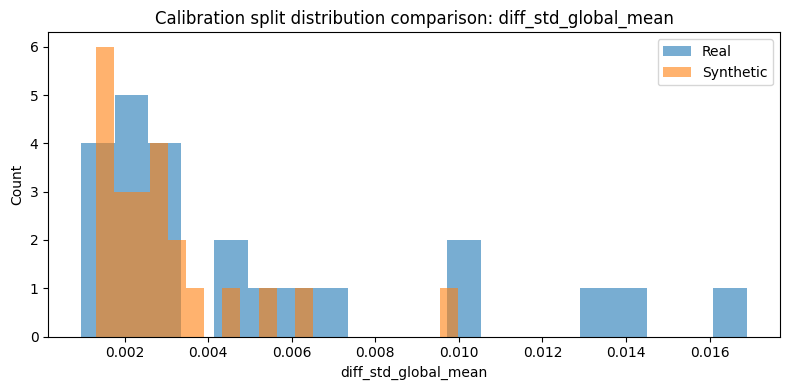

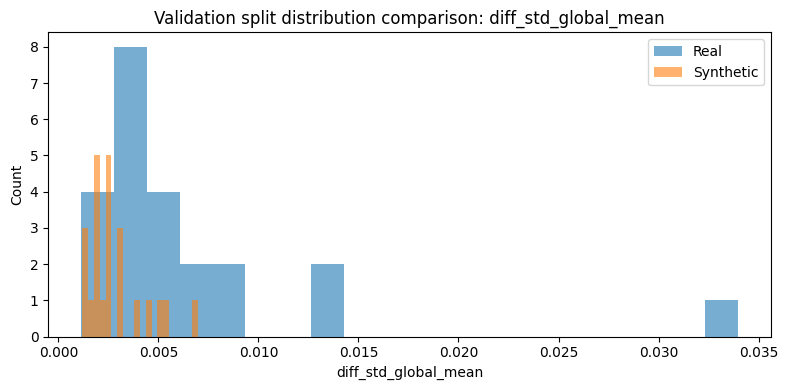

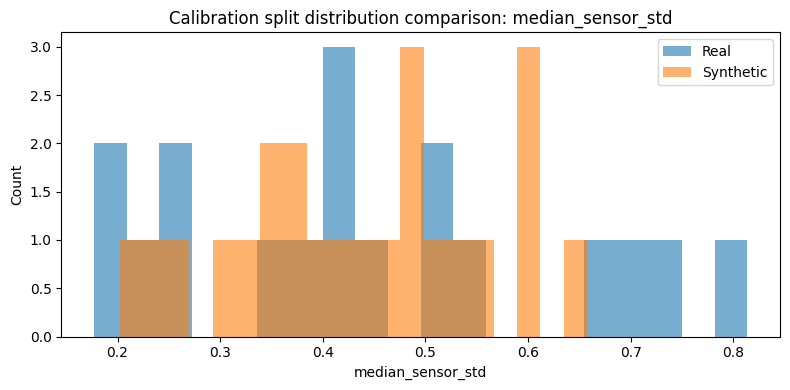

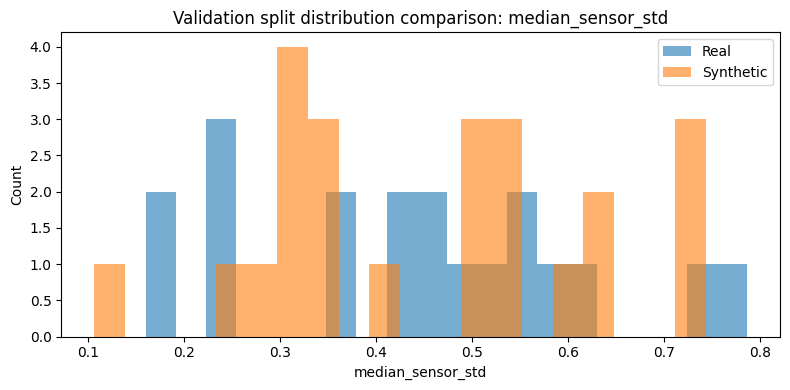

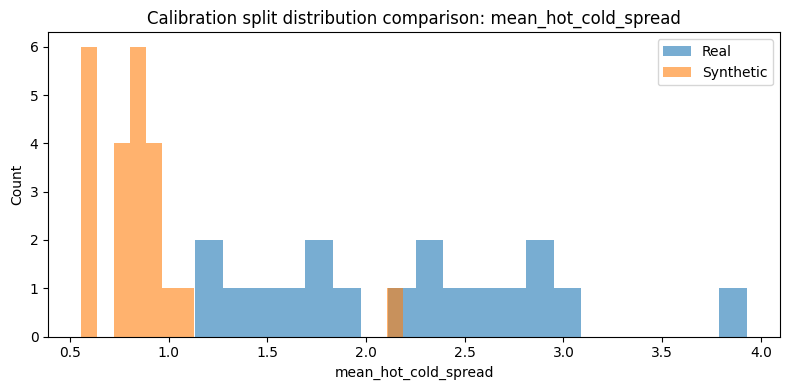

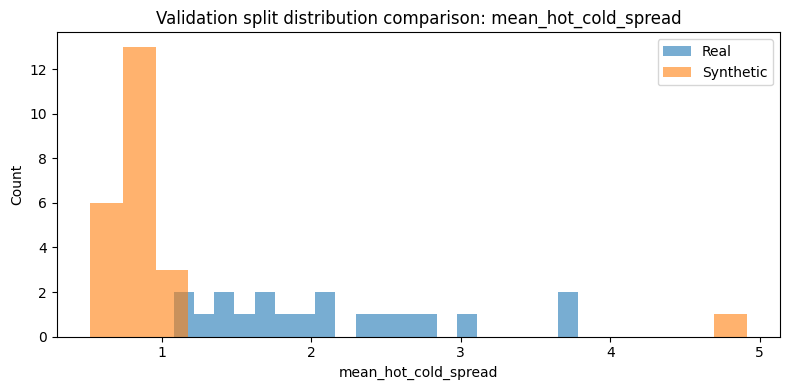

In [ ]:
def plot_median_curve_compare(real_per, synth_per, title: str, path: Path):
    real_curve = median_curve_from_per_session(real_per)
    synth_curve = median_curve_from_per_session(synth_per)

    plt.figure()
    plt.plot(real_curve, label="Real median curve")
    plt.plot(synth_curve, label="Synthetic median curve")
    plt.title(title)
    plt.xlabel("Normalized session time")
    plt.ylabel("Global mean drift from baseline")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.show()
    plt.close()

def plot_distribution_compare(real_per, synth_per, col: str, title: str, path: Path):
    plt.figure()
    plt.hist(real_per[col], bins=20, alpha=0.6, label="Real")
    plt.hist(synth_per[col], bins=20, alpha=0.6, label="Synthetic")
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.show()
    plt.close()

# one representative seed for visual diagnostics
VIS_SEED = 9090
_, synth_calib_vis = simulate_dataset_from_session_spec(
    calib_real_per, curve_bank, increment_bank, best_params, seed=VIS_SEED
)
_, synth_valid_vis = simulate_dataset_from_session_spec(
    valid_real_per, curve_bank, increment_bank, best_params, seed=VIS_SEED
)

plot_median_curve_compare(calib_real_per, synth_calib_vis, "Calibration split: real vs synthetic median curve", PLOT_DIR / "calib_curve_compare.png")
plot_median_curve_compare(valid_real_per, synth_valid_vis, "Validation split: real vs synthetic median curve", PLOT_DIR / "valid_curve_compare.png")

for col in ["total_drift", "diff_std_global_mean", "median_sensor_std", "mean_hot_cold_spread"]:
    plot_distribution_compare(
        calib_real_per, synth_calib_vis, col,
        f"Calibration split distribution comparison: {col}",
        PLOT_DIR / f"calib_dist_{col}.png"
    )
    plot_distribution_compare(
        valid_real_per, synth_valid_vis, col,
        f"Validation split distribution comparison: {col}",
        PLOT_DIR / f"valid_dist_{col}.png"
    )

## 17) Final production generation after validation

Only do this step after checking the QA gate.  
The idea is:

- once parameters are validated,
- use **all real sessions** as the output template specification
- still use the same validated parameters

This gives a final synthetic dataset for downstream work while preserving the stricter validation process above.

In [ ]:
FINAL_SYNTH_PATH = FINAL_DIR / "synthetic_passive_dataset_v3.csv"
FINAL_SYNTH_PER_PATH = FINAL_DIR / "synthetic_passive_per_session_metrics_v3.csv"
FINAL_REPORT_PATH = FINAL_DIR / "final_full_dataset_report_v3.json"
FINAL_LABEL_REPORT_PATH = FINAL_DIR / "final_full_dataset_labelwise_report_v3.csv"

# optional: build final banks from all real data once validation is done
full_curve_bank = session_table[["test_ref", "side_array", "breast_label", "curve"]].copy()
full_increment_bank = {}
for label, sub in session_table.groupby("breast_label"):
    seqs = []
    for arr in sub["diff"]:
        arr = finite_1d(arr)
        if len(arr) >= 20:
            seqs.append(arr)
    full_increment_bank[label] = seqs

final_synth_df, final_synth_per = simulate_dataset_from_session_spec(
    session_spec_df=session_table,
    curve_bank_df=full_curve_bank,
    increment_bank_dict=full_increment_bank,
    params=best_params,
    seed=9999,
)

final_report = calibration_report(session_table, final_synth_per)
final_label_report = calibration_report_by_label(session_table, final_synth_per)

final_synth_df.to_csv(FINAL_SYNTH_PATH, index=False)
final_synth_per.drop(columns=["curve", "diff", "corr"]).to_csv(FINAL_SYNTH_PER_PATH, index=False)
save_json(final_report, FINAL_REPORT_PATH)
if len(final_label_report):
    final_label_report.to_csv(FINAL_LABEL_REPORT_PATH, index=False)

print("Saved:", FINAL_SYNTH_PATH)
print("Saved:", FINAL_SYNTH_PER_PATH)
print("Saved:", FINAL_REPORT_PATH)
display(final_label_report if len(final_label_report) else pd.DataFrame())
print(json.dumps(final_report, indent=2))

Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/final_generation/synthetic_passive_dataset_v3.csv
Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/final_generation/synthetic_passive_per_session_metrics_v3.csv
Saved: /content/drive/MyDrive/clean-cbra/passive_simulator_v3_outputs/final_generation/final_full_dataset_report_v3.json


,drift_med_rel_err,warm_med_rel_err,diff_med_rel_err,sensor_drift_med_rel_err,sensor_std_med_rel_err,spread_med_rel_err,lag1_abs_err,lag3_abs_err,curve_rmse,wd_total_drift,wd_early_warmup,wd_diff_std,wd_sensor_std,wd_spread,corr_mae,score,drift_med_rel_err_pass,warm_med_rel_err_pass,diff_med_rel_err_pass,lag1_abs_err_pass,lag3_abs_err_pass,curve_rmse_pass,sensor_drift_med_rel_err_pass,sensor_std_med_rel_err_pass,spread_med_rel_err_pass,wd_total_drift_pass,wd_early_warmup_pass,wd_diff_std_pass,wd_sensor_std_pass,wd_spread_pass,corr_mae_pass,overall_pass,breast_label
0,0.250923,0.268906,0.308948,0.260046,0.256971,0.658693,0.000010,0.000003,0.276131,0.277042,0.065243,0.002802,0.092227,1.454955,0.006872,4.216426,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,Healthy
1,0.164423,0.198888,0.422321,0.149701,0.148873,0.596390,0.000012,0.000068,0.253917,0.265668,0.073215,0.003194,0.058719,1.263528,0.010190,4.074471,False,False,False,True,True,False,True,True,False,False,True,False,False,False,True,False,Tumor


{
  "drift_med_rel_err": 0.21186331357388008,
  "warm_med_rel_err": 0.2372982883324444,
  "diff_med_rel_err": 0.354591446535762,
  "sensor_drift_med_rel_err": 0.20997774319320653,
  "sensor_std_med_rel_err": 0.21627740520284108,
  "spread_med_rel_err": 0.6384746244415571,
  "lag1_abs_err": 1.4379863949698368e-05,
  "lag3_abs_err": 2.0938075061094352e-05,
  "curve_rmse": 0.26924320030918863,
  "wd_total_drift": 0.2730858440265631,
  "wd_early_warmup": 0.0680155282553444,
  "wd_diff_std": 0.0029381623856829507,
  "wd_sensor_std": 0.07935774477527066,
  "wd_spread": 1.3781513572050204,
  "corr_mae": 0.007777807951613921,
  "score": 4.132597752685146,
  "drift_med_rel_err_pass": false,
  "warm_med_rel_err_pass": false,
  "diff_med_rel_err_pass": false,
  "lag1_abs_err_pass": true,
  "lag3_abs_err_pass": true,
  "curve_rmse_pass": false,
  "sensor_drift_med_rel_err_pass": true,
  "sensor_std_med_rel_err_pass": false,
  "spread_med_rel_err_pass": false,
  "wd_total_drift_pass": false,
  "wd_

## 18) Final verdict block

Read this block at the end of the notebook every time you run it:

- If the **scientific QA gate** is `True`, then the passive simulator is acceptable **for the current passive-data stage**.
- If it is `False`, then the simulator family or search space still needs improvement.
- In that case, inspect:
  - validation repeatability,
  - class imbalance in pass rates,
  - sensor-level mismatch,
  - and correlation-matrix mismatch.

This notebook is intentionally stricter than v2, so a worse result here does **not** necessarily mean the simulator got worse.  
It often means the **evaluation became more honest**.